## Explorando dos dados dos municípios

### Estrutura dos dados

In [69]:
import pandas as pd

df_fact_municipio = pd.read_parquet("../data/silver/meta_alfabetizacao_municipio/meta_alfabetizacao_municipio.parquet")

df_fact_municipio.shape

(10704, 17)

In [2]:
df_fact_municipio.head(10)

,ano,id_municipio,Rede,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,percentual_participacao,ID_Rede,Municipio,Capital,UF
0,2023,4301750,Municipal,NaN,NaN,14.05,23.65,37.00,52.68,67.85,80.0,<NA>,NaN,3,Barão do Triunfo,Falso,RS
1,2024,4301750,Municipal,4.40,NaN,14.05,23.65,37.00,52.68,67.85,80.0,0,92.59,3,Barão do Triunfo,Falso,RS
2,2024,2406908,Municipal,42.86,7.94,14.05,23.65,37.00,52.68,67.85,80.0,1,84.00,3,Lucrécia,Falso,RN
3,2023,2406908,Municipal,4.40,7.94,14.05,23.65,37.00,52.68,67.85,80.0,0,82.14,3,Lucrécia,Falso,RN
4,2023,1718501,Municipal,4.60,8.25,14.48,24.16,37.49,53.03,68.00,80.0,0,95.65,3,Recursolândia,Falso,TO
5,2024,1718501,Municipal,50.29,8.25,14.48,24.16,37.49,53.03,68.00,80.0,2,90.57,3,Recursolândia,Falso,TO
6,2024,2919900,Municipal,12.50,8.39,14.66,24.38,37.70,53.17,68.06,80.0,0,100.00,3,Macururé,Falso,BA
7,2023,2919900,Municipal,4.70,8.39,14.66,24.38,37.70,53.17,68.06,80.0,0,87.76,3,Macururé,Falso,BA
8,2023,2414456,Municipal,NaN,NaN,18.14,28.32,41.34,55.70,69.16,80.0,<NA>,NaN,3,Triunfo Potiguar,Falso,RN
9,2024,2414456,Municipal,10.95,NaN,18.14,28.32,41.34,55.70,69.16,80.0,0,80.43,3,Triunfo Potiguar,Falso,RN


In [3]:
print("===== SHAPE =====")
print(df_fact_municipio.shape)

print("\n===== COLUNAS =====")
print(df_fact_municipio.columns.tolist())

print("\n===== TIPOS =====")
print(df_fact_municipio.dtypes)

print("\n===== NULOS =====")
print(df_fact_municipio.isna().sum())

print("\n===== ANOS =====")
print(sorted(df_fact_municipio["ano"].unique()))

print("\n===== REDES =====")
print(df_fact_municipio["ID_Rede"].value_counts().sort_index())

print("\n===== MUNICÍPIOS =====")
print(df_fact_municipio["id_municipio"].nunique())

===== SHAPE =====
(10704, 17)

===== COLUNAS =====
['ano', 'id_municipio', 'Rede', 'taxa_alfabetizacao', 'meta_alfabetizacao_2024', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026', 'meta_alfabetizacao_2027', 'meta_alfabetizacao_2028', 'meta_alfabetizacao_2029', 'meta_alfabetizacao_2030', 'nivel_alfabetizacao', 'percentual_participacao', 'ID_Rede', 'Municipio', 'Capital', 'UF']

===== TIPOS =====
ano                          Int64
id_municipio                   str
Rede                           str
taxa_alfabetizacao         float64
meta_alfabetizacao_2024    float64
meta_alfabetizacao_2025    float64
meta_alfabetizacao_2026    float64
meta_alfabetizacao_2027    float64
meta_alfabetizacao_2028    float64
meta_alfabetizacao_2029    float64
meta_alfabetizacao_2030    float64
nivel_alfabetizacao          Int64
percentual_participacao    float64
ID_Rede                      Int64
Municipio                      str
Capital                        str
UF                             str
d

In [4]:
df_fact_municipio.isna().sum().sort_values(ascending=False)

meta_alfabetizacao_2024    240
nivel_alfabetizacao        120
taxa_alfabetizacao         120
percentual_participacao    120
ano                          0
meta_alfabetizacao_2025      0
meta_alfabetizacao_2026      0
Rede                         0
id_municipio                 0
meta_alfabetizacao_2028      0
meta_alfabetizacao_2027      0
meta_alfabetizacao_2030      0
meta_alfabetizacao_2029      0
ID_Rede                      0
Municipio                    0
Capital                      0
UF                           0
dtype: int64

In [5]:
df_fact_municipio.duplicated(
    subset=["ano", "id_municipio", "ID_Rede"]
).sum()

np.int64(0)

In [55]:
municipios_por_ano = (
    df_fact_municipio
    .groupby("ano")
    .agg(
        municipios_com_taxa=(
            "taxa_alfabetizacao",
            lambda x: x.notna().sum()
        ),
        municipios_com_meta_2024=(
            "meta_alfabetizacao_2024",
            lambda x: x.notna().sum()
        )
    )
)

print(municipios_por_ano)

      municipios_com_taxa  municipios_com_meta_2024
ano                                                
2023                 5232                      5232
2024                 5352                      5232


In [56]:
municipios_com_taxa_nos_dois_anos = (
    df_fact_municipio[
        df_fact_municipio["taxa_alfabetizacao"].notna()
    ]
    .groupby("id_municipio")["ano"]
    .nunique()
)

quantidade = (
    municipios_com_taxa_nos_dois_anos
    .eq(2)
    .sum()
)

print(quantidade)

5232


### Estatísticas básicas

In [6]:
df_fact_municipio["taxa_alfabetizacao"].describe()

count    10584.000000
mean        61.774719
std         19.527540
min          4.400000
25%         47.600000
50%         62.445000
75%         76.742500
max        100.000000
Name: taxa_alfabetizacao, dtype: float64

In [7]:
df_fact_municipio.groupby("UF")["taxa_alfabetizacao"].mean().sort_values()

UF
SE    33.046667
BA    37.259773
RN    39.520345
TO    42.502764
AC    43.727826
AP    46.316562
AM    46.384752
PA    47.667662
AL    49.114069
RR    51.390000
MS    55.236266
PB    56.838866
RJ    56.858242
MA    62.198314
MT    62.227993
SP    62.496399
RS    62.721995
PE    62.847038
PI    63.095625
RO    65.861048
SC    68.335427
MG    69.092359
PR    74.995473
ES    75.396603
GO    76.490391
CE    89.749701
Name: taxa_alfabetizacao, dtype: float64

In [39]:
media_estado_ano = (
    df_fact_municipio
    .groupby(["UF", "ano"])["taxa_alfabetizacao"]
    .mean()
    .unstack()
    .round(2)
)

# Diferença em pontos percentuais
media_estado_ano["Dif. 23-24 (p.p.)"] = (
    media_estado_ano[2024] - media_estado_ano[2023]
).round(2)

# Ordenar pela diferença, da maior para a menor
media_estado_ano = media_estado_ano.sort_values(
    "Dif. 23-24 (p.p.)",
    ascending=False
)

print(media_estado_ano)


ano   2023   2024  Dif. 23-24 (p.p.)
UF                                  
MG   62.84  75.21              12.37
MS   50.99  59.48               8.49
TO   38.49  46.48               7.99
MT   58.40  66.03               7.63
GO   72.66  80.29               7.63
AP   42.72  49.91               7.19
SE   29.62  36.48               6.86
AL   45.82  52.41               6.59
PI   60.03  66.16               6.13
PB   54.21  59.46               5.25
PE   60.22  65.47               5.25
RR   48.80  53.98               5.18
RN   37.04  41.80               4.76
ES   73.03  77.76               4.73
RJ   55.00  58.68               3.68
SP   60.95  64.03               3.08
PA   46.56  48.73               2.17
MA   61.14  63.25               2.11
RO   65.08  66.63               1.55
SC   67.58  69.04               1.46
CE   89.37  90.13               0.76
BA   37.76  36.76              -1.00
PR   75.92  74.08              -1.84
AM   47.83  45.13              -2.70
AC   48.60  43.51              -5.09
R

In [32]:
regioes = {
    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",
    
    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",
    
    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste",
    
    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",
    
    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul"
}

df_fact_municipio["regiao"] = df_fact_municipio["UF"].map(regioes)

In [33]:
media_regiao_ano = (
    df_fact_municipio
    .groupby(["regiao", "ano"])["taxa_alfabetizacao"]
    .mean()
    .unstack()
    .round(2)
)

print(media_regiao_ano)

ano            2023   2024
regiao                    
Centro-Oeste  64.63  72.43
Nordeste      53.52  56.57
Norte         46.20  49.56
Sudeste       62.16  70.06
Sul           72.88  64.35


Todos os estados da região Centro-Oeste crescem YoY e impacto em um avanço de +8 p.p na região como um todo. Região sul apresenta queda puxado por RS e seguido por PR, SC avança apenas 1,5 p.p

In [51]:
df_rs = df_fact_municipio[
    df_fact_municipio["UF"] == "RS"
].copy()

In [52]:
taxa_rs = (
    df_rs
    .pivot_table(
        index=["id_municipio", "Municipio"],
        columns="ano",
        values="taxa_alfabetizacao",
        aggfunc="mean"
    )
)

print(taxa_rs)

ano                                 2023    2024
id_municipio Municipio                          
4300034      Aceguá                 70.0   52.50
4300059      Água Santa             64.6   55.10
4300109      Agudo                  56.1   56.90
4300208      Ajuricaba              80.1   81.90
4300307      Alecrim                 NaN   33.30
...                                  ...     ...
4323606      Vista Alegre do Prata  95.0   85.70
4323705      Vista Gaúcha           74.3  100.00
4323770      Westfalia              82.9   61.50
4323804      Xangri-lá              56.8   37.90
5005202      Ladário                25.2   33.36

[441 rows x 2 columns]


In [53]:
df_rs_null = (
    df_fact_municipio[
        (df_fact_municipio["UF"] == "RS") &
        (df_fact_municipio["taxa_alfabetizacao"].isna())
    ]
    .groupby("ano")["id_municipio"]
    .nunique()
)

print(df_rs_null)

ano
2023    20
Name: id_municipio, dtype: int64


In [54]:
df_rs = df_fact_municipio[
    df_fact_municipio["UF"] == "RS"
].copy()

taxa_rs = (
    df_rs
    .pivot_table(
        index=["id_municipio", "Municipio"],
        columns="ano",
        values="taxa_alfabetizacao",
        aggfunc="mean"
    )
)

# Diferença 2023 → 2024 em p.p.
taxa_rs["dif_23_24_pp"] = (
    taxa_rs[2024] - taxa_rs[2023]
)

# Municípios com maior queda primeiro
maiores_quedas = (
    taxa_rs
    .dropna(subset=[2023, 2024])
    .sort_values("dif_23_24_pp")
)

print(
    maiores_quedas[
        [2023, 2024, "dif_23_24_pp"]
    ].head(20)
)

ano                                   2023  2024  dif_23_24_pp
id_municipio Municipio                                        
4301073      Arroio do Padre          94.6  18.2         -76.4
4319752      São Vendelino           100.0  25.0         -75.0
4320453      Sério                    85.4  11.1         -74.3
4302584      Bozano                  100.0  27.3         -72.7
4321493      Toropi                  100.0  38.7         -61.3
4310850      Jaboticaba               85.5  25.0         -60.5
4312203      Maximiliano de Almeida   93.8  33.3         -60.5
4321634      Três Arroios            100.0  40.0         -60.0
4313334      Nova Ramada              87.0  28.0         -59.0
4311643      Linha Nova              100.0  41.2         -58.8
4323507      Vista Alegre             90.0  33.3         -56.7
4316477      Salvador das Missões    100.0  44.4         -55.6
4306700      Dona Francisca           81.3  26.7         -54.6
4307203      Erval Grande             92.0  38.8       

RS apresenta queda forte e não parece ausência de dados. Ganhamos confiança nos dados, pois verificando as cidades que mais apresentaram queda no estado (Arroio do Padre e São Vendelino) encontramos uma notícia datada de 2025 sobre a queda nos dois municípios - https://www.jornaldocomercio.com/jornal-cidades/2025/08/1214082-sao-vendelino-e-arroio-do-padre-buscam-melhoras-em-indicadores.html

In [9]:
pd.crosstab(
    df_fact_municipio["ano"],
    df_fact_municipio["nivel_alfabetizacao"]
)

nivel_alfabetizacao,0,1,2,3,4,5
ano,,,,,,
2023,863,738,930,947,836,918
2024,742,691,853,951,974,1141


In [10]:
pd.crosstab(
    df_fact_municipio["ano"],
    df_fact_municipio["nivel_alfabetizacao"],
    normalize="index"
) * 100

nivel_alfabetizacao,0,1,2,3,4,5
ano,,,,,,
2023,16.494648,14.105505,17.775229,18.100153,15.978593,17.545872
2024,13.863976,12.911061,15.937967,17.769058,18.198804,21.319133


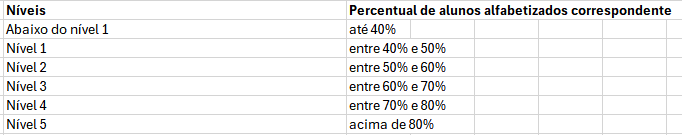

É possível que os municípios estão avançando no % de alunos alfabetizados. Em 2024, 21,3% dos municípios tinham mais de 80% dos alunos até a segunda série do ensino municipal alfabetizados, valor 3,8 p.p acima do observado em 2023.

### Correlação entre os indicadores

In [11]:
df_fact_municipio[
    ["taxa_alfabetizacao", "percentual_participacao"]
].corr()

,taxa_alfabetizacao,percentual_participacao
taxa_alfabetizacao,1.00000,0.28966
percentual_participacao,0.28966,1.00000


In [12]:
df_fact_municipio.groupby("ano")[
    ["taxa_alfabetizacao", "percentual_participacao"]
].corr()

taxa_alfabetizacao  percentual_participacao
ano                                                                      
2023 taxa_alfabetizacao                 1.000000                 0.286984
     percentual_participacao            0.286984                 1.000000
2024 taxa_alfabetizacao                 1.000000                 0.283692
     percentual_participacao            0.283692                 1.000000

In [50]:
df_fact_municipio.groupby("ano")[
    ["taxa_alfabetizacao", "percentual_participacao"]
].corr(method="spearman")

taxa_alfabetizacao  percentual_participacao
ano                                                                      
2023 taxa_alfabetizacao                 1.000000                 0.281627
     percentual_participacao            0.281627                 1.000000
2024 taxa_alfabetizacao                 1.000000                 0.280145
     percentual_participacao            0.280145                 1.000000

### Distância para meta

In [23]:
df_2024 = df_fact_municipio[
    df_fact_municipio["ano"] == 2024
].copy()

df_2024["gap_2024"] = (
    df_2024["meta_alfabetizacao_2024"]
    - df_2024["taxa_alfabetizacao"]
)

In [24]:
df_2024["gap_2024"].describe()

count    5232.000000
mean       -1.114841
std        15.201525
min       -84.270000
25%       -10.812500
50%        -0.980000
75%         7.740000
max        68.900000
Name: gap_2024, dtype: float64

In [27]:
df_2024 = df_fact_municipio[
    df_fact_municipio["ano"] == 2024
].copy()

df_2024["situacao_meta_2024"] = np.select(
    [
        df_2024["taxa_alfabetizacao"] >= df_2024["meta_alfabetizacao_2024"],
        df_2024["taxa_alfabetizacao"] < df_2024["meta_alfabetizacao_2024"]
    ],
    [
        "Atingiu a meta",
        "Abaixo da meta"
    ],
    default="Sem informação"
)

In [28]:
df_2024["situacao_meta_2024"].value_counts()

situacao_meta_2024
Atingiu a meta    2788
Abaixo da meta    2444
Sem informação     120
Name: count, dtype: int64

In [41]:
df_2024 = df_fact_municipio[
    df_fact_municipio["ano"] == 2024
].copy()

df_2024["abaixo_meta"] = (
    df_2024["taxa_alfabetizacao"]
    < df_2024["meta_alfabetizacao_2024"]
)

municipios_meta_estado = (
    df_2024
    .groupby("UF")
    .agg(
        total_municipios=("id_municipio", "nunique"),
        municipios_abaixo_meta=("abaixo_meta", "sum")
    )
)

municipios_meta_estado["%_abaixo_meta"] = (
    municipios_meta_estado["municipios_abaixo_meta"]
    / municipios_meta_estado["total_municipios"]
    * 100
)

municipios_meta_estado = (
    municipios_meta_estado
    .sort_values("municipios_abaixo_meta", ascending=False)
    .round(2)
)

print(municipios_meta_estado)

    total_municipios  municipios_abaixo_meta  %_abaixo_meta
UF                                                         
RS               441                     380          86.17
BA               398                     319          80.15
SP               626                     301          48.08
PR               398                     210          52.76
MG               818                     164          20.05
PB               221                     107          48.42
SC               254                     106          41.73
MA               217                     103          47.47
PI               224                      93          41.52
PA               142                      91          64.08
RN               151                      73          48.34
PE               184                      72          39.13
TO               138                      61          44.20
RJ                92                      54          58.70
MT               140                    

Estados com a maior parte dos municípios abaixo da meta: RS (86.2%), BA (80.15%), PR (52.76%), PA (64.08%), RJ (58.70%), AM (62.96%) e AP (50.00%)

In [42]:
df_2024 = df_fact_municipio[
    df_fact_municipio["ano"] == 2024
].copy()

df_2024["abaixo_meta"] = (
    df_2024["taxa_alfabetizacao"]
    < df_2024["meta_alfabetizacao_2024"]
)

resultado_capital = (
    df_2024
    .groupby("Capital")
    .agg(
        total_municipios=("id_municipio", "nunique"),
        municipios_abaixo_meta=("abaixo_meta", "sum")
    )
)

resultado_capital["%_abaixo_meta"] = (
    resultado_capital["municipios_abaixo_meta"]
    / resultado_capital["total_municipios"]
    * 100
).round(2)

print(resultado_capital)

            total_municipios  municipios_abaixo_meta  %_abaixo_meta
Capital                                                            
Falso                   5330                    2433          45.65
Verdadeiro                22                      11          50.00


In [48]:
df_capitais_2024 = df_fact_municipio[
    (df_fact_municipio["ano"] == 2024) &
    (df_fact_municipio["Capital"] == "Verdadeiro")
].copy()

df_capitais_2024["diferenca_meta"] = (
    df_capitais_2024["taxa_alfabetizacao"]
    - df_capitais_2024["meta_alfabetizacao_2024"]
).round(2)

df_capitais_2024["bateu_meta"] = np.where(
    df_capitais_2024["diferenca_meta"] >= 0,
    "Sim",
    "Não"
)

resultado_capitais = (
    df_capitais_2024[
        [
            "Municipio",
            "taxa_alfabetizacao",
            "meta_alfabetizacao_2024",
            "bateu_meta"
        ]
    ]
    .sort_values("bateu_meta")
)

print(resultado_capitais)

           Municipio  taxa_alfabetizacao  meta_alfabetizacao_2024 bateu_meta
1729        Salvador               36.75                    45.52        Não
1738          Maceió               40.95                    45.58        Não
2255          Macapá               49.14                    49.20        Não
3019           Belém               46.08                    53.42        Não
3475      Rio Branco               55.64                      NaN        Não
3735          Manaus               50.13                    56.80        Não
4072          Cuiabá               46.56                    58.26        Não
4939          Palmas               56.97                    62.20        Não
5705          Recife               54.36                    65.29        Não
6204     Porto Velho               50.84                    67.50        Não
7217        Curitiba               65.96                    71.93        Não
7861       Fortaleza               74.81                    74.95        Não

Chama a atenção que o maior volume de capitais que não batem meta estão no Norte ou Nordeste. Da 9 capitais do Nordeste, 4 não batem meta. Já no Norte o problema é ainda mais grave, pois 6 dos 7 estados não batem a meta e não temos registro de Boa Vista - RR.

Podendo indicar que estados e regiões com renda per capital menor tendem a ter menores taxas de alfabetização.

In [49]:
df_capitais_2024 = df_fact_municipio[
    (df_fact_municipio["ano"] == 2024) &
    (df_fact_municipio["Capital"] == "Verdadeiro")
].copy()

resultado_capitais = (
    df_capitais_2024[
        [
            "Municipio",
            "UF",
            "percentual_participacao"
        ]
    ]
    .sort_values("percentual_participacao")
)

print(resultado_capitais)

           Municipio  UF  percentual_participacao
3019           Belém  PA                    75.65
3735          Manaus  AM                    75.81
4939          Palmas  TO                    76.81
3475      Rio Branco  AC                    81.03
7217        Curitiba  PR                    81.41
4733  Belo Horizonte  MG                    83.08
2739     João Pessoa  PB                    83.59
4072          Cuiabá  MT                    84.05
1551       São Paulo  SP                    85.03
6204     Porto Velho  RO                    85.05
6473         Goiânia  GO                    86.46
4471  Rio de Janeiro  RJ                    86.99
1729        Salvador  BA                    87.86
2890        São Luís  MA                    88.73
2029    Campo Grande  MS                    89.34
1738          Maceió  AL                    91.46
2255          Macapá  AP                    91.69
3017        Teresina  PI                    91.73
6369         Vitória  ES                    92.02


Não existe uma correlação clara não presença na prova, como já tinha sido visto anteriormente pela análise de correlação.

In [72]:
df_ = df_fact_municipio[
    df_fact_municipio["taxa_alfabetizacao"]==39.30
].copy()

df_.head()

,ano,id_municipio,Rede,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,percentual_participacao,ID_Rede,Municipio,Capital,UF
515,2024,2803401,Municipal,39.3,33.27,41.37,49.96,58.55,66.65,73.87,80.0,0,99.28,3,Japoatã,Falso,SE
1746,2023,2903003,Municipal,39.3,45.60,52.10,58.53,64.68,70.38,75.51,80.0,0,95.08,3,Barra do Mendes,Falso,BA
1748,2023,2903300,Municipal,39.3,45.64,52.13,58.55,64.70,70.39,75.51,80.0,0,93.90,3,Barro Preto,Falso,BA
1751,2023,1600279,Municipal,39.3,45.64,52.13,58.55,64.70,70.39,75.51,80.0,0,94.48,3,Laranjal do Jari,Falso,AP
1753,2023,3513405,Municipal,39.3,45.68,52.17,58.58,64.72,70.40,75.52,80.0,0,90.85,3,Cruzeiro,Falso,SP


### Compreendendo os Outliers

In [59]:
df_23_24 = df_fact_municipio[
    df_fact_municipio["ano"].isin([2023, 2024])
].copy()

# Mantém apenas municípios com taxa nos dois anos
municipios_completos = (
    df_23_24
    .groupby("id_municipio")["ano"]
    .nunique()
)

municipios_completos = municipios_completos[
    municipios_completos == 2
].index

df_23_24 = df_23_24[
    df_23_24["id_municipio"].isin(municipios_completos)
]

# Coloca 2023 e 2024 lado a lado
analise = (
    df_23_24
    .pivot_table(
        index=["id_municipio", "Municipio", "UF"],
        columns="ano",
        values=[
            "taxa_alfabetizacao",
            "meta_alfabetizacao_2024"
        ],
        aggfunc="mean"
    )
)

# Achata as colunas
analise.columns = [
    f"{col[0]}_{col[1]}"
    for col in analise.columns
]

analise = analise.reset_index()

# Evolução da alfabetização
analise["variacao_23_24_pp"] = (
    analise["taxa_alfabetizacao_2024"]
    - analise["taxa_alfabetizacao_2023"]
).round(2)

# Distância para a meta
analise["gap_meta_2024"] = (
    analise["meta_alfabetizacao_2024_2024"]
    - analise["taxa_alfabetizacao_2024"]
).round(2)

# Critérios de atenção
analise["baixa_alfabetizacao"] = (
    analise["taxa_alfabetizacao_2024"] < 50
)

analise["abaixo_meta"] = (
    analise["taxa_alfabetizacao_2024"]
    < analise["meta_alfabetizacao_2024_2024"]
)

analise["queda_yoy"] = (
    analise["variacao_23_24_pp"] < 0
)

# Classificação final
analise["precisa_atencao"] = (
    analise["baixa_alfabetizacao"]
    & analise["abaixo_meta"]
    & analise["queda_yoy"]
)

# Ranking dos municípios críticos
municipios_criticos = (
    analise[
        analise["precisa_atencao"]
    ]
    .sort_values(
        ["gap_meta_2024", "variacao_23_24_pp"],
        ascending=False
    )
)

print(
    municipios_criticos[
        [
            "Municipio",
            "UF",
            "taxa_alfabetizacao_2023",
            "taxa_alfabetizacao_2024",
            "variacao_23_24_pp",
            "meta_alfabetizacao_2024_2024",
            "gap_meta_2024"
        ]
    ].head(30)
)

                   Municipio  UF  taxa_alfabetizacao_2023  \
4825                   Sério  RS                     85.4   
4465         Arroio do Padre  RS                     94.6   
4636              Jaboticaba  RS                     85.5   
4813           São Vendelino  RS                    100.0   
4802             São Nicolau  RS                     57.9   
4563          Dona Francisca  RS                     81.3   
4491                  Bozano  RS                    100.0   
4693             Nova Ramada  RS                     87.0   
363           Monte do Carmo  TO                     70.0   
4823        Sentinela do Sul  RS                     73.8   
4233                   Caibi  SC                     75.5   
322         Chapada de Areia  TO                     50.0   
3750                Taquaral  SP                     75.0   
4706          Pantano Grande  RS                     72.5   
4717            Pedro Osório  RS                     67.7   
4883            Vista Al

In [60]:
municipios_extremos = [
    "Sério",
    "Arroio do Padre",
    "Jaboticaba",
    "São Vendelino",
    "São Nicolau",
    "Dona Francisca"
]

df_extremos = (
    df_fact_municipio[
        df_fact_municipio["Municipio"].isin(municipios_extremos) &
        df_fact_municipio["ano"].isin([2023, 2024])
    ]
    [
        [
            "Municipio",
            "UF",
            "ano",
            "taxa_alfabetizacao",
            "percentual_participacao",
            "nivel_alfabetizacao"
        ]
    ]
    .sort_values(["Municipio", "ano"])
)

print(df_extremos)

             Municipio  UF   ano  taxa_alfabetizacao  percentual_participacao  \
10540  Arroio do Padre  RS  2023                94.6                    83.33   
10514  Arroio do Padre  RS  2024                18.2                    84.62   
9257    Dona Francisca  RS  2023                81.3                    84.21   
8940    Dona Francisca  RS  2024                26.7                    93.75   
9969        Jaboticaba  RS  2023                85.5                    93.33   
10240       Jaboticaba  RS  2024                25.0                   100.00   
4778       São Nicolau  RS  2023                57.9                    90.48   
4781       São Nicolau  RS  2024                 7.1                    82.35   
10364    São Vendelino  RS  2023               100.0                    93.75   
9065     São Vendelino  RS  2024                25.0                   100.00   
10465            Sério  RS  2023                85.4                    84.21   
10163            Sério  RS  

In [62]:
df_23_24 = df_fact_municipio[
    df_fact_municipio["ano"].isin([2023, 2024])
].copy()


municipios_completos = (
    df_23_24
    .groupby("id_municipio")["ano"]
    .nunique()
)

municipios_completos = municipios_completos[
    municipios_completos == 2
].index

df_23_24 = df_23_24[
    df_23_24["id_municipio"].isin(municipios_completos)
].copy()

analise = (
    df_23_24
    .pivot_table(
        index=[
            "id_municipio",
            "Municipio",
            "UF"
        ],
        columns="ano",
        values="taxa_alfabetizacao",
        aggfunc="mean"
    )
)


analise.columns = [
    f"taxa_alfabetizacao_{col}"
    for col in analise.columns
]

analise = analise.reset_index()


analise["variacao_23_24_pp"] = (
    analise["taxa_alfabetizacao_2024"]
    - analise["taxa_alfabetizacao_2023"]
).round(2)


resumo_uf = (
    analise
    .groupby("UF")
    .agg(
        taxa_media_2023=(
            "taxa_alfabetizacao_2023",
            "mean"
        ),
        taxa_media_2024=(
            "taxa_alfabetizacao_2024",
            "mean"
        ),
        variacao_media_23_24_pp=(
            "variacao_23_24_pp",
            "mean"
        ),
        mediana_variacao_23_24_pp=(
            "variacao_23_24_pp",
            "median"
        ),
        desvio_padrao_variacao=(
            "variacao_23_24_pp",
            "std"
        ),
        municipios=(
            "id_municipio",
            "count"
        )
    )
    .round(2)
    .sort_values(
        "variacao_media_23_24_pp"
    )
)


print("\n========== EVOLUÇÃO DA ALFABETIZAÇÃO POR UF ==========")

print(resumo_uf)


========== EVOLUÇÃO DA ALFABETIZAÇÃO POR UF ==========
    taxa_media_2023  taxa_media_2024  variacao_media_23_24_pp  \
UF                                                              
RS            73.03            52.88                   -19.99   
AC            48.60            43.51                   -10.39   
PR            75.92            74.08                    -1.68   
AM            47.83            45.13                    -1.52   
BA            37.76            36.76                    -1.02   
CE            89.37            90.13                     0.77   
SC            67.58            69.04                     1.73   
RO            65.08            66.63                     2.11   
MA            61.14            63.25                     2.16   
PA            46.56            48.73                     2.62   
SP            60.95            64.03                     3.13   
RJ            55.00            58.68                     3.22   
ES            73.03            77.

In [64]:
df_23_24 = df_fact_municipio[
    df_fact_municipio["ano"].isin([2023, 2024])
].copy()


municipios_completos = (
    df_23_24
    .groupby("id_municipio")["ano"]
    .nunique()
)

municipios_completos = municipios_completos[
    municipios_completos == 2
].index

df_23_24 = df_23_24[
    df_23_24["id_municipio"].isin(municipios_completos)
].copy()

analise = (
    df_23_24
    .pivot_table(
        index=[
            "id_municipio",
            "Municipio",
            "UF"
        ],
        columns="ano",
        values="taxa_alfabetizacao",
        aggfunc="mean"
    )
)


analise.columns = [
    f"taxa_alfabetizacao_{col}"
    for col in analise.columns
]

analise = analise.reset_index()


analise["variacao_23_24_pp"] = (
    analise["taxa_alfabetizacao_2024"]
    - analise["taxa_alfabetizacao_2023"]
).round(2)

print("Impacto do RS")
analise[analise["UF"] == "RS"]["variacao_23_24_pp"].describe()


Impacto do RS


count    421.000000
mean     -19.990119
std       17.115072
min      -76.400000
25%      -29.800000
50%      -20.000000
75%      -10.300000
max       54.100000
Name: variacao_23_24_pp, dtype: float64

In [66]:
print("Brasil sem RS")
analise[analise["UF"] != "RS"]["variacao_23_24_pp"].describe()

Brasil sem RS


count    4811.000000
mean        4.781214
std        14.972592
min       -56.470000
25%        -3.875000
50%         3.750000
75%        13.075000
max        89.900000
Name: variacao_23_24_pp, dtype: float64

In [67]:
rs = analise[analise["UF"] == "RS"].copy()

print("Percentual de municípios com queda:")
print(
    (rs["variacao_23_24_pp"] < 0).mean() * 100
)

print("\nPercentual com queda superior a 10 p.p.:")
print(
    (rs["variacao_23_24_pp"] < -10).mean() * 100
)

print("\nPercentual com queda superior a 20 p.p.:")
print(
    (rs["variacao_23_24_pp"] < -20).mean() * 100
)

Percentual de municípios com queda:
85.4875283446712

Percentual com queda superior a 10 p.p.:
71.65532879818595

Percentual com queda superior a 20 p.p.:
46.93877551020408
